# Time series graphics

The first thing to do in any data analysis task is to plot the data. Graphs enable many features of the data to be visualised, including patterns, unusual observations, changes over time, and relationships between variables. The features that are seen in plots of the data must then be incorporated, as much as possible, into the forecasting methods to be used. Just as the type of data determines what forecasting method to use, it also determines what graphs are appropriate. But before we produce graphs, we need to set up our time series in Python.

In [ ]:
# # Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter)
# get_ipython().run_line_magic('run', '../_setup.py')

In [ ]:
# load additional libraries
import statsmodels.api as sm
from scipy.stats import pearsonr
from statsmodels.graphics.tsaplots import plot_acf


## I. DataFrame objects 

A time series consists of a sequence of numerical observations along with information about when those numbers were recorded. 

Sometimes a primary observation is accompanied by related data known as ***covariates*** or ***exogenous variables***. 

This data is commonly stored in a two-dimensional tabular data structure called a dataframe. We will focus on the pandas DataFrame in this book.


In [105]:
# Index and Columns in Pandas DataFrames
import pandas as pd 

df = pd.DataFrame({
    'Year': list(range(2015, 2020)), 
    'Observations': [100, 150, 200, 250, 300]
})

# Individual columns can be accessed and manipulated as Series objects:
year_df = df.set_index('Year')
print(year_df)

      Observations
Year              
2015           100
2016           150
2017           200
2018           250
2019           300


### Timestamps and periods 
Time series observations may be associated with instants in time or spans of time. pandas supports these concepts through pd.Timestamp and pd.Period classes, respectively:

In [106]:
print(repr(pd.Timestamp("2020-01")))
print(repr(pd.Period("2020-01")))

Timestamp('2020-01-01 00:00:00')
Period('2020-01', 'M')


pandas provides many utilities for converting between text strings and dedicated timestamp or period representations. Internally, timestamps are stored with nanosecond precision by default, but for convenience a partial specification is sufficient to refer to the earliest instant matching the input. For periods, the same logic is used to parse the start of the time span, and the duration is inferred from the precision provided unless the frequency is indicated via the freq= argument:

In [107]:
print(repr(pd.Timestamp("2020")))
print(repr(pd.Timestamp("2020-01-01 12:34")))
print(repr(pd.Period("2020-01-01")))
print(repr(pd.Period("2020-01-01", freq="M")))

Timestamp('2020-01-01 00:00:00')
Timestamp('2020-01-01 12:34:00')
Period('2020-01-01', 'D')
Period('2020-01', 'M')


Timestamp sequences can be conveniently constructed using pd.to_datetime() or pd.date_range():

In [108]:
ts_few = pd.to_datetime(["2020-01-01", "2020-01-02", "2020-01-03"])
ts_range = pd.date_range("2020-01-01", "2020-01-02", freq="8h")
print(ts_few)
print(ts_range)

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03'], dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 08:00:00',
               '2020-01-01 16:00:00', '2020-01-02 00:00:00'],
              dtype='datetime64[ns]', freq='8h')


The .to_period() and .to_timestamp() methods allow conversions between timestamp and period. The .to_period() method will infer the period duration unless the freq= argument is specified. For example,

In [109]:
print(ts_range.to_period())
print(ts_range.to_period(freq="D"))
print(ts_range.to_period(freq="W"))
print(ts_range.to_period().to_timestamp())
# Note that W-SUN indicates weeks starting on Monday and ending on Sunday.

PeriodIndex(['2020-01-01 00:00', '2020-01-01 08:00', '2020-01-01 16:00',
             '2020-01-02 00:00'],
            dtype='period[8h]')
PeriodIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-02'], dtype='period[D]')
PeriodIndex(['2019-12-30/2020-01-05', '2019-12-30/2020-01-05',
             '2019-12-30/2020-01-05', '2019-12-30/2020-01-05'],
            dtype='period[W-SUN]')
DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 08:00:00',
               '2020-01-01 16:00:00', '2020-01-02 00:00:00'],
              dtype='datetime64[ns]', freq='8h')


Both timestamps and period start times can be converted to strings with custom formatting using .strftime():

In [110]:
print(ts_few.strftime("%m/%d/%Y"))
print(ts_range.to_period().strftime("%Y %b ~ %H:%M"))

Index(['01/01/2020', '01/02/2020', '01/03/2020'], dtype='object')
Index(['2020 Jan ~ 00:00', '2020 Jan ~ 08:00', '2020 Jan ~ 16:00',
       '2020 Jan ~ 00:00'],
      dtype='object')


pandas automatically converts between Index and Series types as needed when these sequences are used as the data or index in a DataFrame. In Series form, date-time related methods and attributes are nested under the .dt accessor. For example:

In [111]:
df = pd.DataFrame({"ts": ts_few})
df = df.assign(
    period=df["ts"].dt.to_period(),
    yr=df["ts"].dt.year,
    str=df["ts"].dt.strftime("%A, %B %-d"),
).set_index("ts")
df

,period,yr,str
ts,,,
2020-01-01,2020-01-01,2020,2020-01-01 00:00:00
2020-01-02,2020-01-02,2020,2020-01-02 00:00:00
2020-01-03,2020-01-03,2020,2020-01-03 00:00:00


### Working with time series dataframes

We can manipulate DataFrame objects using pandas methods such as .assign(), .rename(), .drop(), .groupby(), and .agg(), along with slicing operations such as [] and .loc[]. To illustrate these, we will use the PBS dataset, containing sales data on pharmaceutical products in Australia.

In [112]:
from pathlib import Path    

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

print(BASE_DIR)

pbs = (
    pd.read_csv(DATA_DIR / "PBS_unparsed.csv", parse_dates=["Month"])
    [["Month", "Concession", "Type", "ATC1", "ATC2", "Scripts", "Cost"]]
)
pbs

d:\Documents\GitHub\-Time-Series-Analysis-and-Forecasting-methods-


,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
0,1991-07-01,Concessional,Co-payments,A,A01,18228,67877.0
1,1991-08-01,Concessional,Co-payments,A,A01,15327,57011.0
2,1991-09-01,Concessional,Co-payments,A,A01,14775,55020.0
3,1991-10-01,Concessional,Co-payments,A,A01,15380,57222.0
4,1991-11-01,Concessional,Co-payments,A,A01,14371,52120.0
...,...,...,...,...,...,...,...
67591,2008-02-01,General,Safety net,Z,Z,135,1591.0
67592,2008-03-01,General,Safety net,Z,Z,15,276.0
67593,2008-04-01,General,Safety net,Z,Z,11,165.0
67594,2008-05-01,General,Safety net,Z,Z,21,278.0


This contains monthly data on Medicare Australia prescription data from July 1991 to June 2008. These are classified according to various concession types, and Anatomical Therapeutic Chemical (ATC) indexes. For this example, we are interested in the Cost time series (total cost of scripts in Australian dollars).

We have already used [] to select a subset of the available columns. We can use .loc[] to extract rows pertaining to A10 scripts.

In [113]:
a10 = pbs.loc[pbs["ATC2"] == "A10"]
a10

,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
1524,1991-07-01,Concessional,Co-payments,A,A10,89733,2092878.0
1525,1991-08-01,Concessional,Co-payments,A,A10,77101,1795733.0
1526,1991-09-01,Concessional,Co-payments,A,A10,76255,1777231.0
1527,1991-10-01,Concessional,Co-payments,A,A10,78681,1848507.0
1528,1991-11-01,Concessional,Co-payments,A,A10,70554,1686458.0
...,...,...,...,...,...,...,...
52339,2008-02-01,General,Safety net,A,A10,10869,530709.0
52340,2008-03-01,General,Safety net,A,A10,1119,51773.0
52341,2008-04-01,General,Safety net,A,A10,721,36289.0
52342,2008-05-01,General,Safety net,A,A10,1947,101233.0


Next we can simplify the resulting object by using .drop() to remove columns not needed in subsequent analysis.

In [114]:
a10 = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
)
a10

,Month,Concession,Type,Scripts,Cost
1524,1991-07-01,Concessional,Co-payments,89733,2092878.0
1525,1991-08-01,Concessional,Co-payments,77101,1795733.0
1526,1991-09-01,Concessional,Co-payments,76255,1777231.0
1527,1991-10-01,Concessional,Co-payments,78681,1848507.0
1528,1991-11-01,Concessional,Co-payments,70554,1686458.0
...,...,...,...,...,...
52339,2008-02-01,General,Safety net,10869,530709.0
52340,2008-03-01,General,Safety net,1119,51773.0
52341,2008-04-01,General,Safety net,721,36289.0
52342,2008-05-01,General,Safety net,1947,101233.0


Another useful method is .agg() which allows us to aggregate data either across all rows or, when used with .groupby(), within groups based on one or more columns in the DataFrame. For example, we may wish to compute total cost per month regardless of the Concession or Type keys.

In [115]:
total_cost_df = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost": "sum"})
    .rename(columns={"Cost": "TotalC"})
)
total_cost_df

,Month,TotalC
0,1991-07-01,3526591.0
1,1991-08-01,3180891.0
2,1991-09-01,3252221.0
3,1991-10-01,3611003.0
4,1991-11-01,3565869.0
...,...,...
199,2008-02-01,21654285.0
200,2008-03-01,18264945.0
201,2008-04-01,23107677.0
202,2008-05-01,22912510.0


We can create or update columns using the assign() method. Here we remove the rename operation and change the units of Cost from dollars to millions of dollars:

In [116]:
total_cost_df = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost": "sum"})
    .assign(Cost=lambda x: (x["Cost"] / 1e6).round(1))
)
total_cost_df

,Month,Cost
0,1991-07-01,3.5
1,1991-08-01,3.2
2,1991-09-01,3.3
3,1991-10-01,3.6
4,1991-11-01,3.6
...,...,...
199,2008-02-01,21.7
200,2008-03-01,18.3
201,2008-04-01,23.1
202,2008-05-01,22.9


### The seasonal period
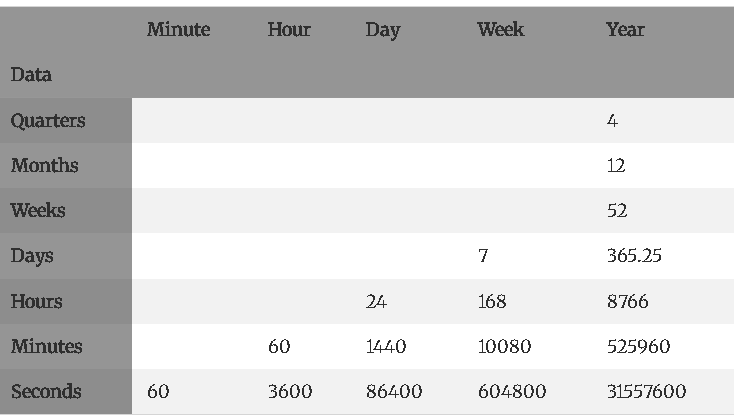

## II. Time plots

For time series data, the obvious graph to start with is a time plot. That is, the observations are plotted against the time of observation, with consecutive observations joined by straight lines. Figure 2.1 shows the weekly economy passenger load on Ansett airlines between Australia’s two largest cities (Melbourne and Sydney).


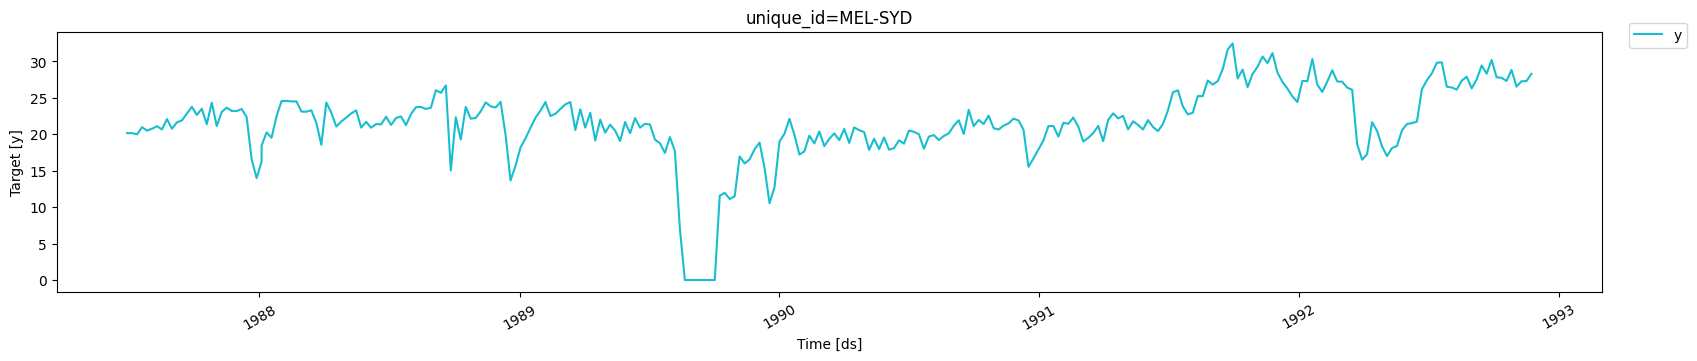

In [117]:
from utilsforecast.plotting import plot_series

melsyd_economy = (
    pd.read_csv(DATA_DIR / "ansett.csv", parse_dates=["ds"])
    .loc[lambda x: (x["Airports"] == "MEL-SYD")
        & (x["Class"] == "Economy")]
    .rename(columns={"Airports": "unique_id"})
    .assign(y=lambda x: x["y"] / 1000)
)
plot_series(
    df=melsyd_economy, id_col="unique_id", time_col="ds", target_col="y")

For plotting series, we will often use the plot_series() function from the utilsforecast library. The function needs these parameters:

- df: Input dataframe (aka pandas DataFrame)
- id_col: Series identifier column (aka unique id)
- time_col: Timestamp (aka index)
- target_col: Target variable column (aka measurement)

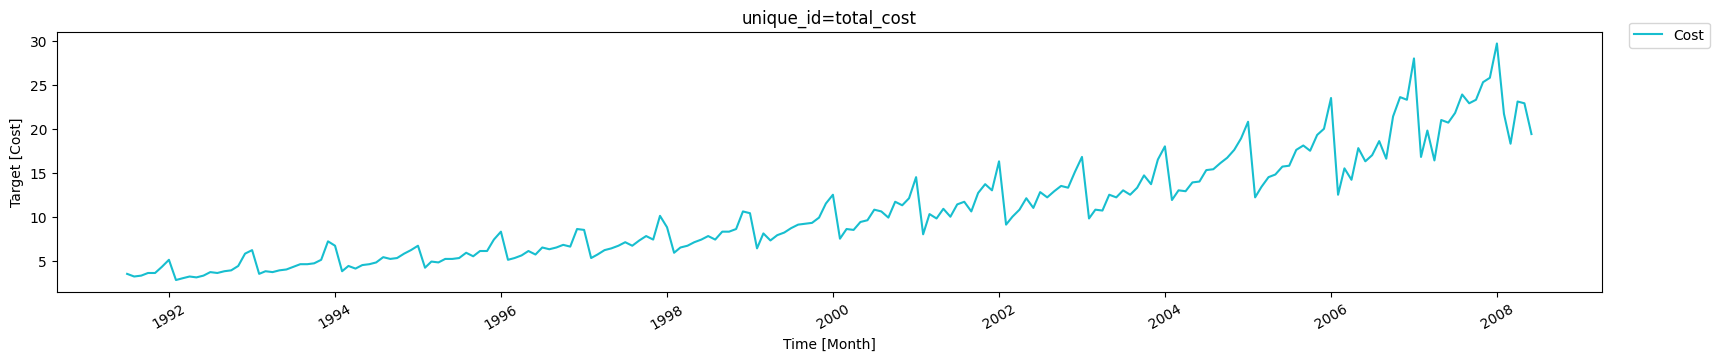

In [118]:
plot_series(total_cost_df.assign(unique_id="total_cost"),
    time_col="Month", target_col="Cost")

## III. Time series patterns

**Trend**: A trend exists when there is a long-term increase or decrease in the data. It does not have to be linear. Sometimes we will refer to a trend as “changing direction”, when it might go from an increasing trend to a decreasing trend.

**Seasonal**: A seasonal pattern occurs when a time series is affected by seasonal factors such as the time of the year, the day of the week or the hour of the day. Seasonality is always of a fixed and known period. 

**Cyclic**: A cycle occurs when the data exhibit rises and falls that are not of a fixed frequency. These fluctuations are usually due to economic conditions, and are often related to the “business cycle”. 

Many people confuse cyclic behaviour with seasonal behaviour, but they are really quite different. If the fluctuations are not of a fixed frequency then they are cyclic; if the frequency is unchanging and associated with some aspect of the calendar, then the pattern is seasonal. In general, the average length of cycles is longer than the length of a seasonal pattern, and the magnitudes of cycles tend to be more variable than the magnitudes of seasonal patterns.

Many time series include trend, cycles and seasonality. When choosing a forecasting method, we will first need to identify the time series patterns in the data, and then choose a method that is able to capture the patterns properly.

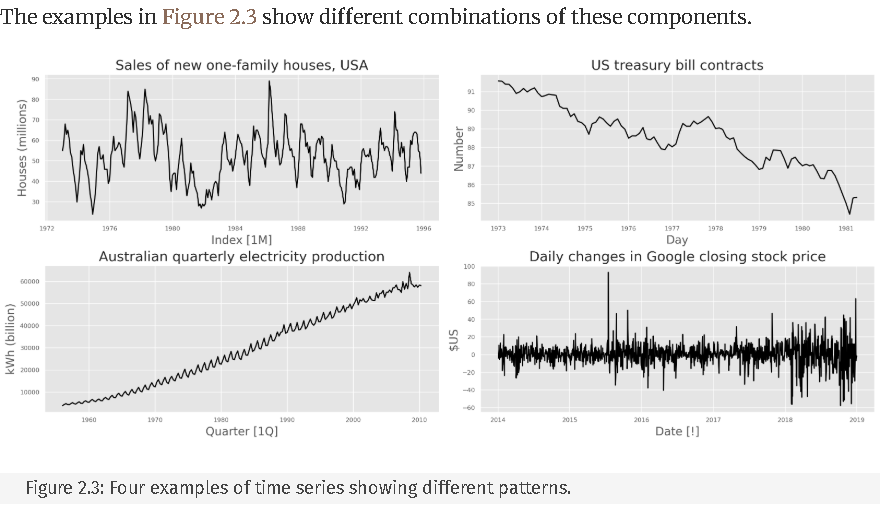

1. The monthly housing sales (top left) show strong seasonality within each year, as well as some strong cyclic behaviour with a period of about 6–10 years. There is no apparent trend in the data over this period.
2. The US treasury bill contracts (top right) show results from the Chicago market for 100 consecutive trading days in 1981. Here there is no seasonality, but an obvious downward trend. Possibly, if we had a much longer series, we would see that this downward trend is actually part of a long cycle, but when viewed over only 100 days it appears to be a trend.
3. The Australian quarterly electricity production (bottom left) shows a strong increasing trend, with strong seasonality. There is no evidence of any cyclic behaviour here.
4. The daily change in the Google closing stock price (bottom right) has no trend, seasonality or cyclic behaviour. There are random fluctuations which do not appear to be predictable, and no strong patterns that would help with developing a forecasting model.

## IV. Seasonal plots 



C:\Users\My PC\AppData\Local\Temp\ipykernel_20792\326418007.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


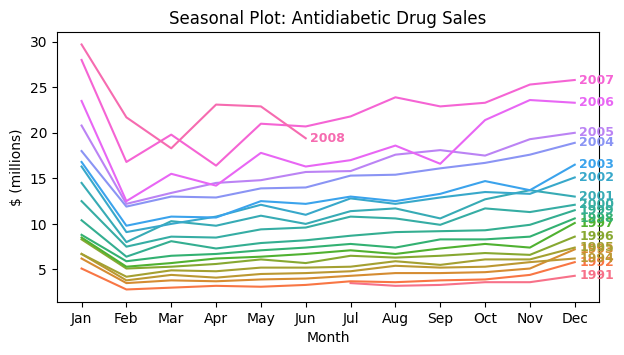

In [119]:
import seaborn as sns
df = total_cost_df.assign(
    Month_name=total_cost_df["Month"].dt.strftime("%b"),
    Year=total_cost_df["Month"].dt.year,
    Month_num=total_cost_df["Month"].dt.month,
)
unique_years = df["Year"].unique()
year_palette = sns.color_palette("husl", n_colors=len(unique_years))
fig, ax = plt.subplots()
sns.lineplot(data=df, x="Month_num", y="Cost",
  hue="Year", palette=year_palette, legend=False, ax=ax)

ax.set(
    title="Seasonal Plot: Antidiabetic Drug Sales",
    xlabel="Month",
    ylabel="$ (millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
)
min_year = unique_years.min()
for year, subset in df.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + .1
    y = subset["Cost"].iloc[-1]
    color = year_palette[year - min_year]
    ax.text(x, y, str(year),
        ha="left", va="center", fontsize=9, weight="bold", color=color)
fig.show()

There is a large jump in sales in January each year. These are probably sales in late December as customers stockpile before the end of the calendar year, but the sales are not registered with the government until a week or two later. The graph also shows an unusually small number of sales in March 2008 (most other years show an increase between February and March). The small number of sales in June 2008 is probably due to incomplete counting of sales when the data were collected.

## V. Seasonal subseries plots 

An alternative plot that emphasises the seasonal patterns is where the data for each season are collected together in separate mini time plots.

C:\Users\My PC\AppData\Local\Temp\ipykernel_20792\3576046290.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


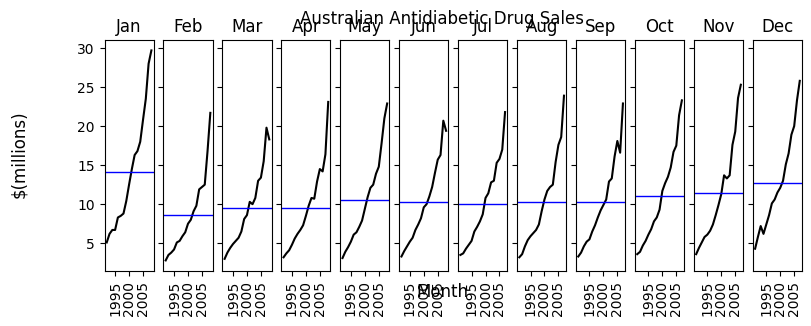

In [120]:
df = total_cost_df.assign(
    year=total_cost_df["Month"].dt.year,
    month_name=total_cost_df["Month"].dt.month_name(),
    month_idx=total_cost_df["Month"].dt.month,
)

fig, axes = plt.subplots(1, 12, figsize=(9, 3), sharey=True)
for ax, ((_, month_name), month_df) in zip(
        axes, df.groupby(["month_idx", "month_name"])):
    mean_cost = month_df["Cost"].mean()
    ax.plot(month_df["year"], month_df["Cost"], color="k")
    ax.axhline(mean_cost, color="b", linewidth=1)
    ax.set(title=month_name[:3], xlabel="")
    ax.tick_params(axis="x", rotation=90)

fig.suptitle("Australian Antidiabetic Drug Sales")
fig.supxlabel("Month")
fig.supylabel("$(millions)")
fig.show()

The blue horizontal lines indicate the means for each month. This form of plot enables the underlying seasonal pattern to be seen clearly, and also shows the changes in seasonality over time. It is especially useful in identifying changes within particular seasons.

### Example: Australian holiday tourism
Australian quarterly vacation data provides an interesting example of how these plots can reveal information. First we need to extract the relevant data from the tourism dataframe. All the usual pandas wrangling functions apply. To get the total visitor nights spent on Holiday by State for each quarter (i.e., ignoring Regions) we can use the following code.

In [121]:
tourism = pd.read_csv(DATA_DIR / "tourism.csv", parse_dates=["ds"])
trips = (
    tourism.loc[lambda x: x["Purpose"] == "Holiday"]
    .groupby(["State", "ds"], as_index=False)
    .agg({"y": "sum"})
)
trips

,State,ds,y
0,ACT,1998-01-01,196.218550
1,ACT,1998-04-01,126.770597
2,ACT,1998-07-01,110.679645
3,ACT,1998-10-01,170.472206
4,ACT,1999-01-01,107.779245
...,...,...,...
635,Western Australia,2016-10-01,982.752589
636,Western Australia,2017-01-01,1134.352019
637,Western Australia,2017-04-01,997.852225
638,Western Australia,2017-07-01,879.988533


C:\Users\My PC\AppData\Local\Temp\ipykernel_20792\779369796.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


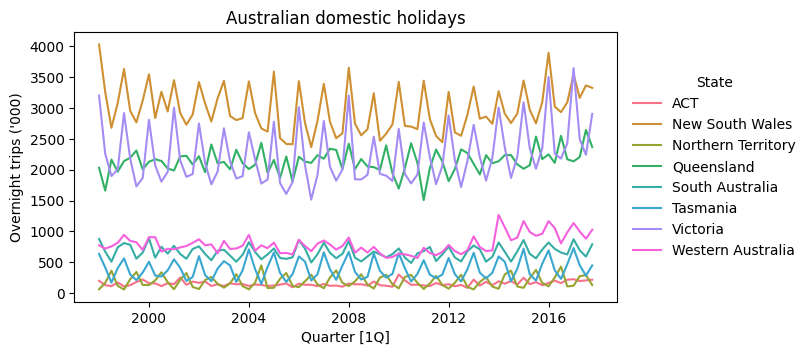

In [122]:
fig, ax = plt.subplots()
palette = sns.color_palette("husl", trips["State"].nunique())
sns.lineplot(data=trips, x="ds", y="y", hue="State", palette=palette)
ax.set(
    title="Australian domestic holidays",
    ylabel="Overnight trips ('000)",
    xlabel="Quarter [1Q]",
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=False, borderaxespad=0, title="State")
fig.show()
# Time plots of each series show that there is strong seasonality for most states, 
# but that the seasonal peaks do not coincide.

C:\Users\My PC\AppData\Local\Temp\ipykernel_20792\2782811923.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


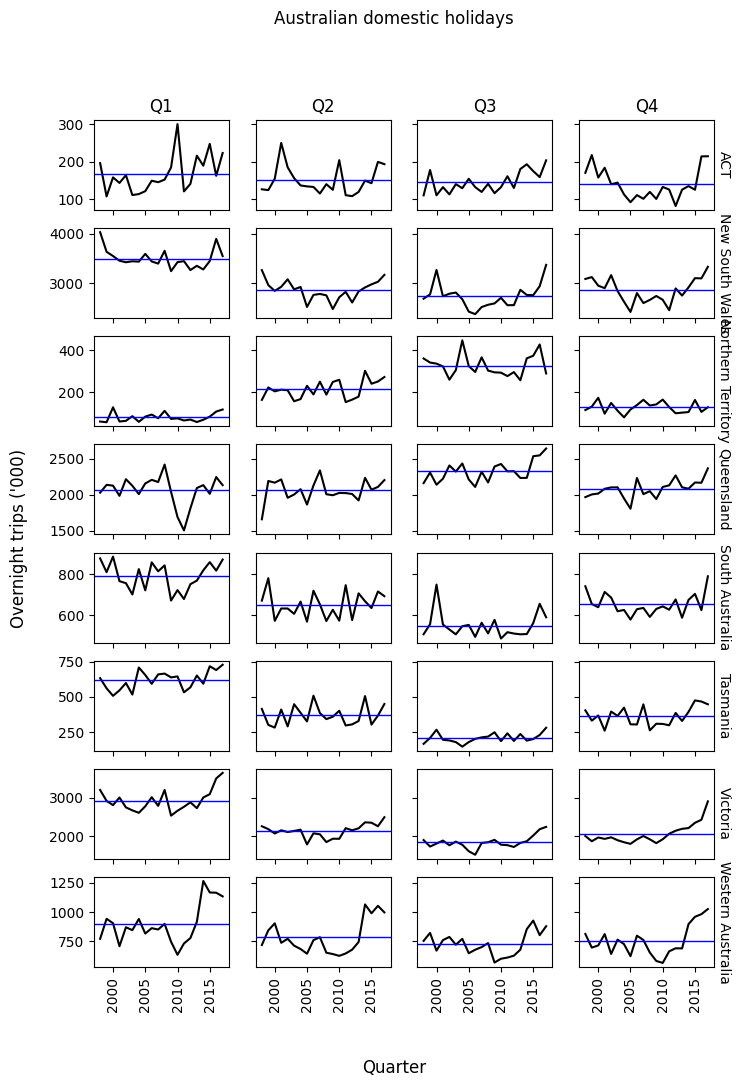

In [123]:
df = trips.assign(
    Quarter="Q" + trips["ds"].dt.quarter.astype("string"),
    Year=trips["ds"].dt.year,
)
num_states, num_years = df[["State", "Year"]].nunique()
palette = sns.color_palette("husl", num_years)

fig, axes = plt.subplots(num_states, 4,
    sharex=True, sharey="row", figsize=(8, 11))
for ax, ((state, quarter), sq_df) in zip(
        axes.flat, df.groupby(["State", "Quarter"])):
    ax.plot(sq_df["Year"], sq_df["y"], color="k")
    ax.axhline(sq_df["y"].mean(), color="b", linewidth=1)
    ax.tick_params(axis="x", rotation=90)
    xticks = sq_df["Year"].loc[lambda x: (x % 5) == 0]
    if ax in axes[0]:
        ax.set(title=quarter, xticks=xticks)
    if ax in axes[:, -1]:
        ax.text(1.02, 0.5, state, va="center", ha="left", rotation=270,
            size="medium", transform=ax.transAxes)
fig.suptitle("Australian domestic holidays")
fig.supxlabel("Quarter")
fig.supylabel("Overnight trips ('000)")
fig.show()

This figure makes it evident that Western Australian tourism has jumped markedly in recent years, while Victorian tourism has increased in Q1 and Q4 but not in the middle of the year.

## VI. Scatterplots 

The graphs discussed so far are useful for visualising individual time series. It is also useful to explore relationships between time series.

## VII. Lag plots 

C:\Users\My PC\AppData\Local\Temp\ipykernel_20792\513694781.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


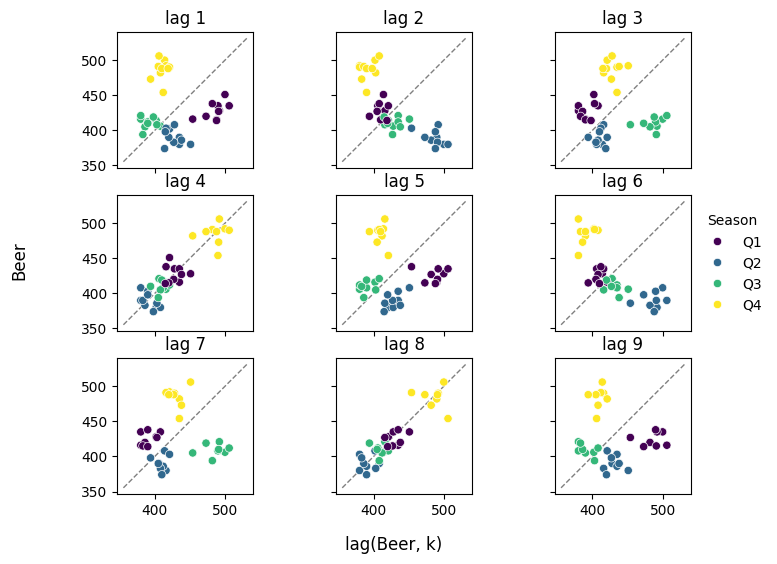

In [124]:
beer = (
    pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates=["ds"])
    [["ds", "Beer"]]
    .loc[lambda x: x["ds"] >= "2000"]
    .assign(Season=lambda x: "Q" + x["ds"].dt.quarter.astype("string"))
    .rename(columns={"Beer": "y"})
)
lims = .95 * beer["y"].min(), 1.05 * beer["y"].max()
cmap = plt.get_cmap("viridis")
colors = {
    season: cmap(i / 3)
    for i, season in enumerate(beer["Season"].unique())
}
fig, axes = plt.subplots(3, 3, figsize=(8, 6), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    lag = i + 1
    df = beer.assign(lag=beer["y"].shift(lag))
    sns.scatterplot(data=df, x="lag", y="y", hue="Season",
        palette=colors, ax=ax)
    ax.plot(lims, lims, color=".5", ls="--", lw=1, zorder=-1)
    ax.set(title=f"lag {lag}", xlabel="", ylabel="", aspect="equal")
    ax.get_legend().remove()
axes[1, -1].legend(loc="center left", title="Season",
    bbox_to_anchor=(1.05, 0.5), frameon=False, borderaxespad=0)
fig.supxlabel("lag(Beer, k)")
fig.supylabel("Beer")
fig.show()

Here the colours indicate the quarter of the variable on the vertical axis. The relationship is strongly positive at lags 4 and 8, reflecting the strong seasonality in the data. The negative relationship seen for lags 2 and 6 occurs because peaks (in Q4) are plotted against troughs (in Q2).

## VIII. Autocorrelation

Just as correlation measures the extent of a linear relationship between two variables, autocorrelation measures the linear relationship between **lagged values** of a time series.

There are several autocorrelation coefficients, corresponding to each panel in the lag plot. For example, $r_{1}$ measures the relationship between $y_{t}$ and $y_{t-1}$, $r_{2}$ measures the relationship between $y_{t}$ and $y_{t-2}$, and so on.

the value of $r_{k}$ can be written as 
$$
r_{k} = \frac{\sum_{t=k+1}^T (y_{t}-\bar{y}) (y_{t-k}-\bar{y})}{\sum_{t=1}^T(y_{t}-\bar{y})^2}
$$
where $T$ is the length of the time series. The autocorrelation coefficients make up the autocorrelation function or ACF.


In [125]:
acf = sm.tsa.acf(beer["y"], nlags=9, fft=False, bartlett_confint=False)
acf_df = pd.Series(acf, name="ACF").to_frame().rename_axis("lag")
acf_df[1:]

,ACF
lag,
1,-0.052981
2,-0.758175
3,-0.026234
4,0.802205
5,-0.077471
6,-0.657451
7,0.001195
8,0.707254
9,-0.088756


The values in the ACF column are $r_{1}, ..., r_{9}$, corresponding to the nine scatterplots. We usually plot the ACF to see how the correlations change with the lag $k$. The plot is sometimes known as **a correlogram**.

C:\Users\My PC\AppData\Local\Temp\ipykernel_20792\970896520.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


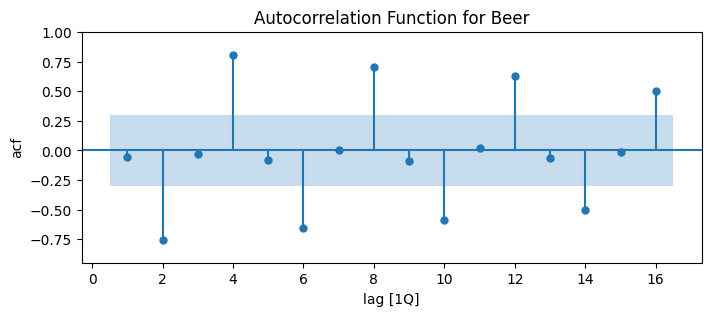

In [126]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(beer["y"], lags=16, ax=ax,
    zero=False, bartlett_confint=False, auto_ylims=True)
ax.set(
    title="Autocorrelation Function for Beer",
    xlabel="lag [1Q]", ylabel="acf",
)
fig.show()

we see that:

- $r_{4}$ is higher than for the other lags. This is due to the seasonal pattern in the data: the peaks tend to be four quarters apart and the troughs tend to be four quarters apart.
- $r_{2}$ is more negative than for the other lags because troughs tend to be two quarters behind peaks.
- The gray shaded regions indicate whether the correlations are significantly different from zero 

### Trend and seasonality in ACF plots

When data have a trend, the autocorrelations for small lags tend to be large and positive because observations nearby in time are also nearby in value. So the ACF of a trended time series tends to have positive values that slowly decrease as the lags increase.

When data are seasonal, the autocorrelations will be larger for the seasonal lags (at multiples of the seasonal period) than for other lags.

When data are both trended and seasonal, you see a combination of these effects. The total_cost_df data plotted in Figure 2.2 shows both trend and seasonality. Its ACF is shown in Figure 2.21. The slow decrease in the ACF as the lags increase is due to the trend, while the “scalloped” shape is due to the seasonality.

C:\Users\My PC\AppData\Local\Temp\ipykernel_20792\1131514431.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


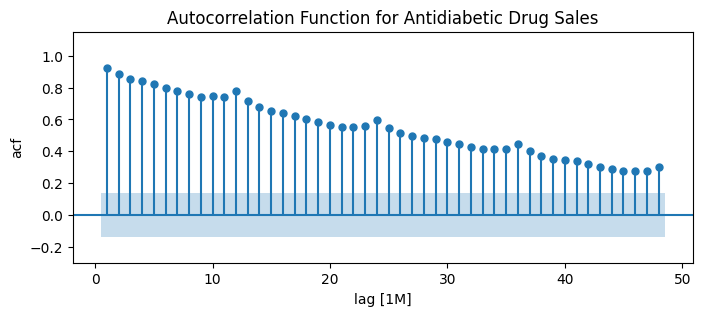

In [127]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(total_cost_df["Cost"], lags=48, ax=ax,
    zero=False, bartlett_confint=False, auto_ylims=True)
ax.set(
    title="Autocorrelation Function for Antidiabetic Drug Sales",
    xlabel="lag [1M]", ylabel="acf", ylim=(-0.3, None),
)
fig.show()

### White noise

Time series that show no autocorrelation are called white noise.



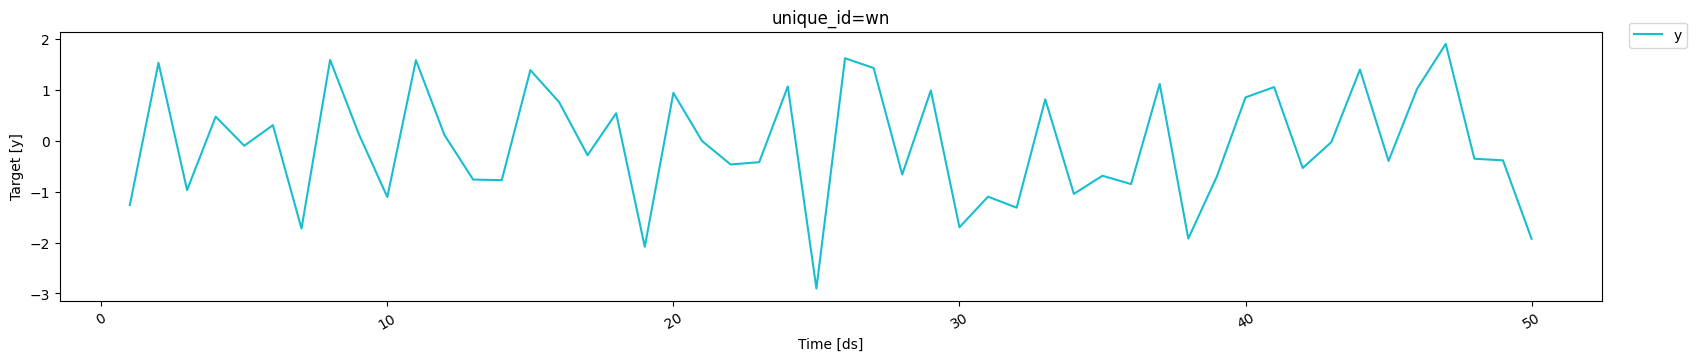

In [128]:
import numpy as np 

plt.rcParams["figure.figsize"] = [7, 3.5]
random = np.random.RandomState(30)
wn = pd.DataFrame({
    "y": random.normal(0, 1, 50),
    "ds": np.arange(1, 51),
    "unique_id": "wn",
})
plot_series(wn, target_col="y")

C:\Users\My PC\AppData\Local\Temp\ipykernel_20792\475787391.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


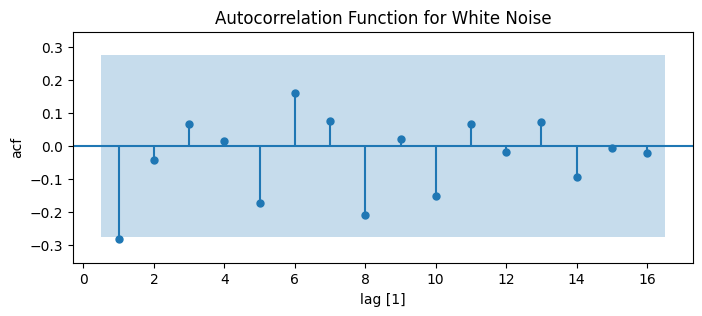

In [129]:


fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(wn["y"], lags=16, ax=ax,
    zero=False, bartlett_confint=False, auto_ylims=True)
ax.set(
    title="Autocorrelation Function for White Noise",
    xlabel="lag [1]", ylabel="acf",
)
fig.show()

Khi bạn vẽ biểu đồ ACF (Autocorrelation Function) để xem các Lags (độ trễ) có tương quan với hiện tại hay không?

Về mặt thống kê, các phần mềm tính toán dải này bằng công thức $\pm 1.96 / \sqrt{N}$ (với $N$ là số lượng điểm dữ liệu).
- Ý nghĩa: Nếu thanh biểu đồ (bar) của một Lag cụ thể nằm bên trong dải này, hệ thống đang nói với bạn rằng: "Sự tương quan này quá nhỏ, nó chỉ là sự dao động ngẫu nhiên thôi, về mặt thống kê có thể coi nó bằng 0 (không có ý nghĩa thống kê)".
- Ngược lại, nếu thanh bar vượt ra ngoài dải 95%, điều đó có nghĩa là: "Sự tương quan này là có thật (statistically significant), **quá khứ đang thực sự ảnh hưởng đến hiện tại**".

for example, Giả sử bạn thấy thanh bar tại Lag_7 vượt ra khỏi dải 95%. Điều này có nghĩa là sai số của ngày hôm nay vẫn đang có quan hệ mật thiết với sai số của 7 ngày trước.
- Kết luận: Mô hình của bạn đang quá tệ, nó đã "bỏ lỡ" (undermodeling) tính chu kỳ theo tuần (7 ngày) trong dữ liệu. Bạn bắt buộc phải quay lại bước Feature Engineering, thêm Lag_7 vào làm biến đầu vào, hoặc đổi thuật toán tốt hơn.

### Further Reading